# Eksperyment pierwszy
Eksperyment, w którym definiujemy dwa zbiory z różnicami w wielkości komórek. Utworzone zostaną dwa zbiory z różnicą w rozmiarze komórek w zbiorze testowym. Ma to na celu sprawdzenie czy istnieje
różnica w MSE

In [1]:
from builders.simple_generator import generate_image, generate_batch
from src.builders.image_builder import ImageGenerator
from src.utils.classes.config import GenerationConfig

conf1 = GenerationConfig()
conf1.distribution.algorithm = 'clustered'
komorka1 = ImageGenerator(conf1)

conf = GenerationConfig()
conf.axes.mean_x = 22
conf.axes.mean_y = 16
conf.axes.std_x = 6

conf.distribution.algorithm = 'clustered'

komorka2 = ImageGenerator(conf)




In [2]:
tranning_set1 = komorka1.build_batch(5000)
validaion_set1 = komorka1.build_batch(1000)
normal_size_set1 = komorka1.build_batch(2000)

large_size_set1 = komorka2.build_batch(2000)

Generated 5 centers
Generated 8 centers
Generated 7 centers
Generated 7 centers
Generated 6 centers
Generated 7 centers
Generated 8 centers
Generated 10 centers
Generated 6 centers
Generated 10 centers
Generated 5 centers
Generated 7 centers
Generated 4 centers
Generated 6 centers
Generated 9 centers
Generated 9 centers
Generated 6 centers
Generated 9 centers
Generated 10 centers
Generated 9 centers
Generated 9 centers
Generated 8 centers
Generated 5 centers
Generated 8 centers
Generated 7 centers
Generated 8 centers
Generated 9 centers
Generated 5 centers
Generated 9 centers
Generated 8 centers
Generated 7 centers
Generated 8 centers
Generated 7 centers
Generated 9 centers
Generated 5 centers
Generated 7 centers
Generated 6 centers
Generated 9 centers
Generated 8 centers
Generated 8 centers
Generated 10 centers
Generated 5 centers
Generated 7 centers
Generated 8 centers
Generated 7 centers
Generated 9 centers
Generated 9 centers
Generated 11 centers
Generated 8 centers
Generated 6 cen

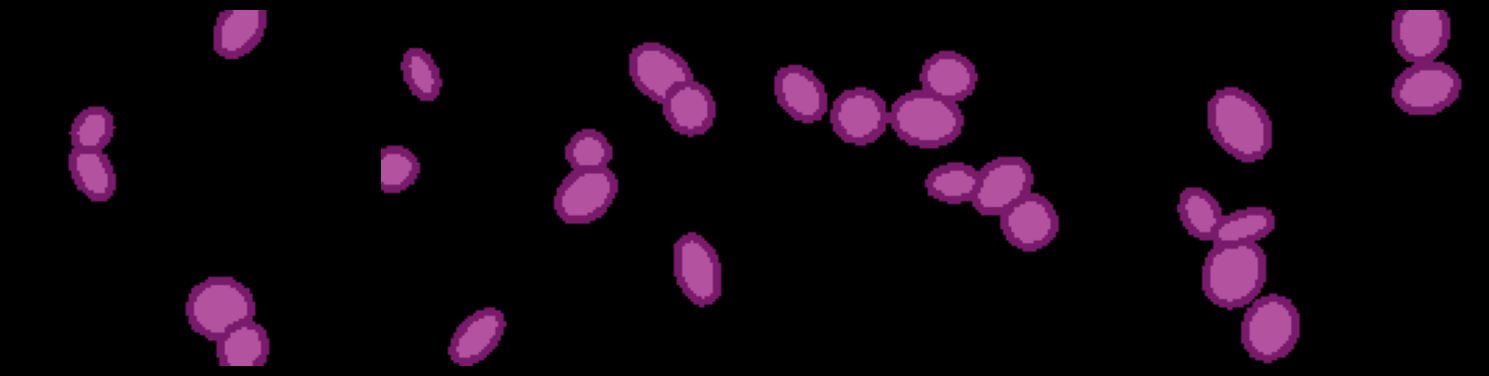

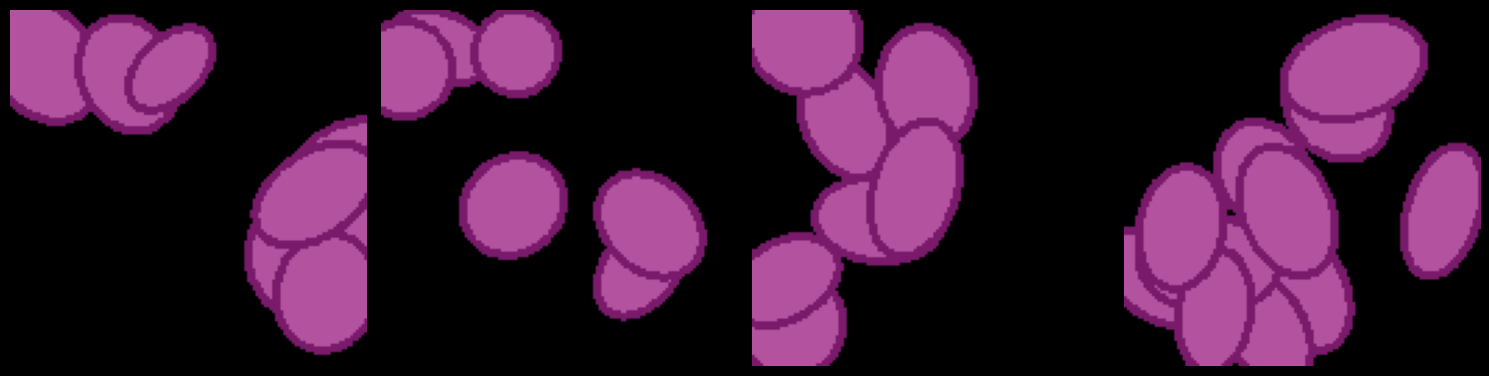

In [3]:
from src.visualization.visualize_output import show_images

show_images(tranning_set1[:4])
show_images(large_size_set1[:4])

In [4]:
import numpy as np


def preprocess(data_list):
    return np.array(data_list, dtype='float32') / 255.

x_train = preprocess(tranning_set1)
x_val = preprocess(validaion_set1)
x_test_normal1 = preprocess(normal_size_set1)
x_test_large = preprocess(large_size_set1)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 140ms/step - accuracy: 0.8807 - loss: 0.1062 - mse: 0.0085 - val_accuracy: 0.9076 - val_loss: 0.0822 - val_mse: 0.0016
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 144ms/step - accuracy: 0.3900 - loss: 0.0805 - mse: 0.0013 - val_accuracy: 0.1441 - val_loss: 0.0803 - val_mse: 0.0011
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 143ms/step - accuracy: 0.3288 - loss: 0.0795 - mse: 0.0011 - val_accuracy: 0.6166 - val_loss: 0.0795 - val_mse: 9.6736e-04
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 140ms/step - accuracy: 0.6579 - loss: 0.0789 - mse: 9.2156e-04 - val_accuracy: 0.6763 - val_loss: 0.0790 - val_mse: 7.9355e-04
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 140ms/step - accuracy: 0.7449 - loss: 0.0783 - mse: 7.3689e-04 - val_accuracy: 0.7744 - val_loss: 0.0786 - val_mse: 7.0410e-04
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 137ms/step - accuracy: 0.7854 - loss: 0.0782 - mse: 7.0322e-04 - val_accuracy: 0.7641 - val_loss: 0.0785 - val_mse: 6.441

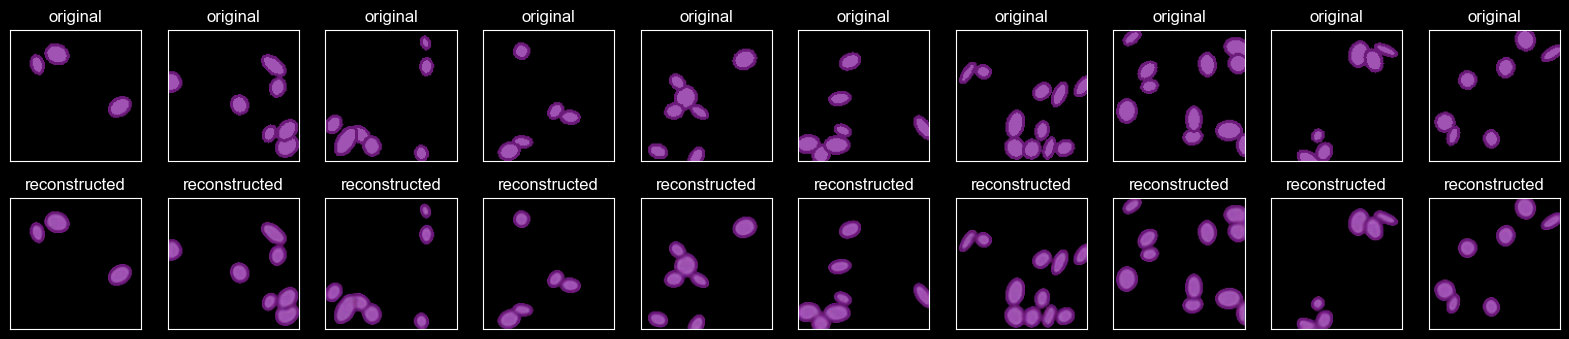

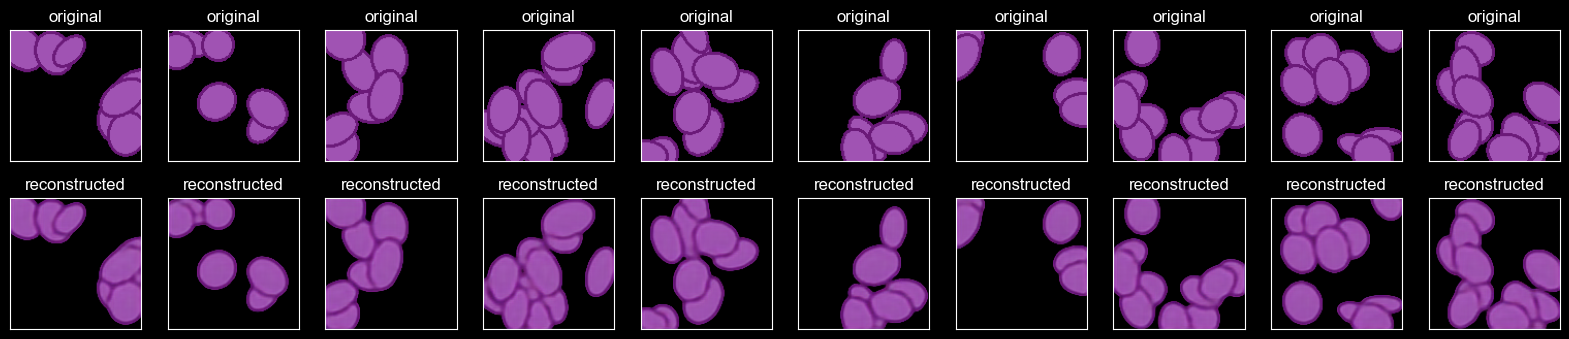

In [5]:
import keras
import numpy as np
from src.models.main import print_diag
from src.visualization.visualize_output import visualize_output
from src.models.encoder_convolutional import Encoder_conv

enkoder = Encoder_conv()

enkoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.0001,
    restore_best_weights=True
)

history = enkoder.fit(
    x_train, x_train,
    epochs=50,
    shuffle=True,
    callbacks=[early_stopping],
    validation_data=(x_val, x_val),
    verbose=1
)
decoded_normal1 = enkoder.predict(x_test_normal1)
decoded_large = enkoder.predict(x_test_large)

mse_normal = enkoder.evaluate(x_test_normal1, x_test_normal1, verbose=0)[0]
mse_large = enkoder.evaluate(x_test_large, x_test_large, verbose=0)[0]

print(f"\nTrening zakończony po {len(history.history['loss'])} epokach.")
print(f"MSE Normal: {mse_normal:.6f}")
print(f"MSE Large:  {mse_large:.6f}")

visualize_output(x_test_normal1, decoded_normal1, 10)

visualize_output(x_test_large, decoded_large, 10)

Trening zakończony po 15 epokach. Wyniki błedu średniokwadratowego MSE przedstawiają się następująco:

Komórki normalne : 0,085
Komórki powiękosze: 0,24

Zauważono znacznie większy błąd w komórkach powiększonych. Jest to spowodowane inną strukturą wygenerowanych, co wprowadza zmiany w rozkładzie pikseli. Jednakże mimo wzrotsu błędu model nie utracił zdolności do poprawnej klasyfikacji kluczowych cech dla komórek.

Enkoder jest w stanie rozpoznawać komórki w podobnym kształcie, ale o różnych wymiarach.


In [6]:
import pandas as pd

temp = [{'Eksperyment': 'MSE Normal', 'Wynik': mse_normal},
        {'Eksperyment': 'MSE Large', 'Wynik': mse_large}
]

mse_dataset = pd.DataFrame(temp, columns=['Eksperyment', 'Wynik'])
mse_dataset


,Eksperyment,Wynik
0,MSE Normal,0.077211
1,MSE Large,0.233353


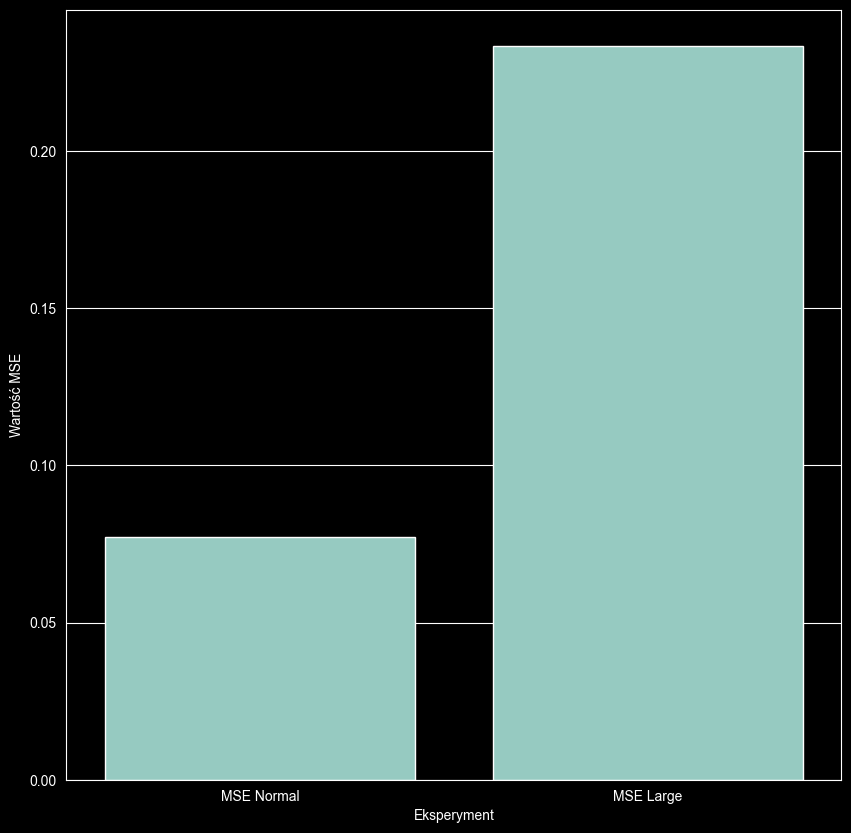

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()


# Eksperyment drugi
zmiana kolorów w drugim zbiorze testowym

In [8]:
from builders.simple_generator import generate_image
from src.builders.image_builder import ImageGenerator
from src.utils.classes.config import GenerationConfig
from src.builders.simple_generator import generate_batch


color_conf = GenerationConfig()
color_conf.nucleus.base_color = (134,80,34)
color_conf.nucleus.border_color = (29,40,182)
kolor_komorki = ImageGenerator(color_conf)




In [9]:
color_test_set2 = kolor_komorki.build_batch(2000)
tranning_set2 = generate_batch(5000)
validaion_set2 = generate_batch(1000)
normal_test_set2 = generate_batch(2000)

Generated 14 centers
Generated 14 centers
Generated 13 centers
Generated 14 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 12 centers
Generated 13 centers
Generated 14 centers
Generated 14 centers
Generated 14 centers
Generated 14 centers
Generated 14 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 13 centers
Generated 13 centers
Generated 12 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 13 centers
Generated 18 centers
Generated 15 centers
Generated 15 centers
Generated 13 centers
Generated 18 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 13 centers
Generated 16 centers
Generated 16 centers
Generated 14 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 16 centers
Generated 17 centers
Generated 15 centers
Generated 16 

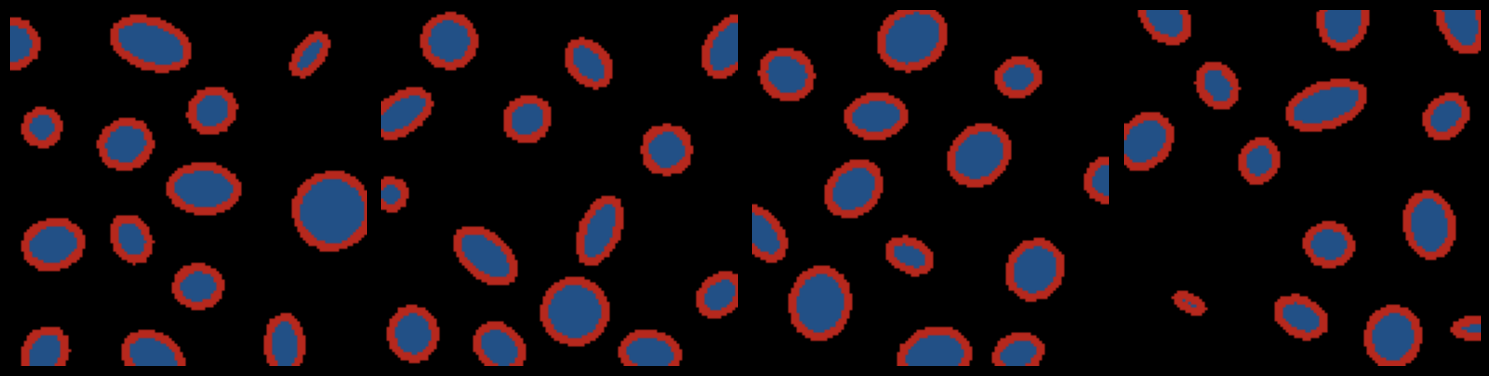

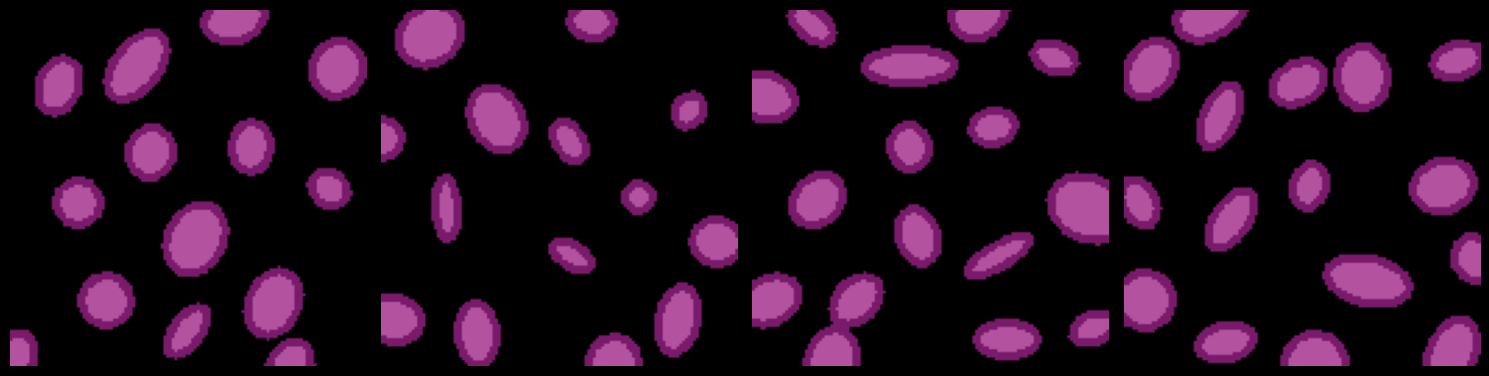

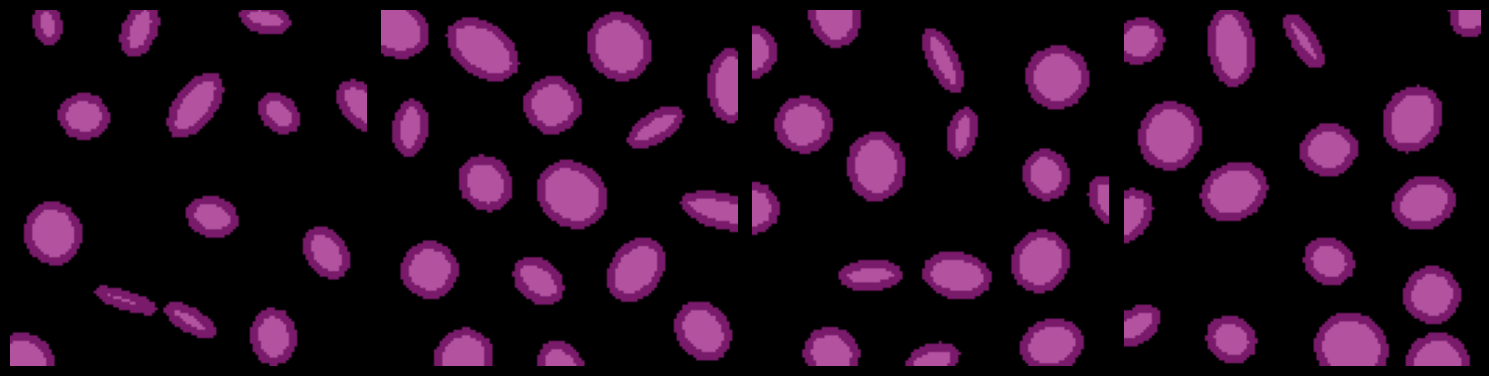

In [10]:
from src.visualization.visualize_output import show_images

show_images(color_test_set2[:4])
show_images(tranning_set2[:4])
show_images(validaion_set2[:4])

In [11]:
x_test_color = preprocess(color_test_set2)
x_test_normal2 = preprocess(normal_test_set2)
x_val_set = preprocess(validaion_set2)
x_training_set = preprocess(tranning_set2)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 137ms/step - accuracy: 0.6969 - loss: 0.1916 - mse: 0.0123 - val_accuracy: 0.3149 - val_loss: 0.1561 - val_mse: 0.0023
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 134ms/step - accuracy: 0.2778 - loss: 0.1559 - mse: 0.0020 - val_accuracy: 0.2635 - val_loss: 0.1535 - val_mse: 0.0016
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 135ms/step - accuracy: 0.3131 - loss: 0.1543 - mse: 0.0016 - val_accuracy: 0.4458 - val_loss: 0.1522 - val_mse: 0.0013
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 135ms/step - accuracy: 0.5645 - loss: 0.1529 - mse: 0.0012 - val_accuracy: 0.6150 - val_loss: 0.1525 - val_mse: 0.0014
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 134ms/step - accuracy: 0.6430 - loss: 0.1526 - mse: 0.0011 - val_accuracy: 0.6644 - val_loss: 0.1513 - val_mse: 0.0011
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 134ms/step - accuracy: 0.6727 - loss: 0.1524 - mse: 0.0011 - val_accuracy: 0.6942 - val_loss: 0.1509 - val_mse: 9.6281e-04
Epoch 7/50
157/157

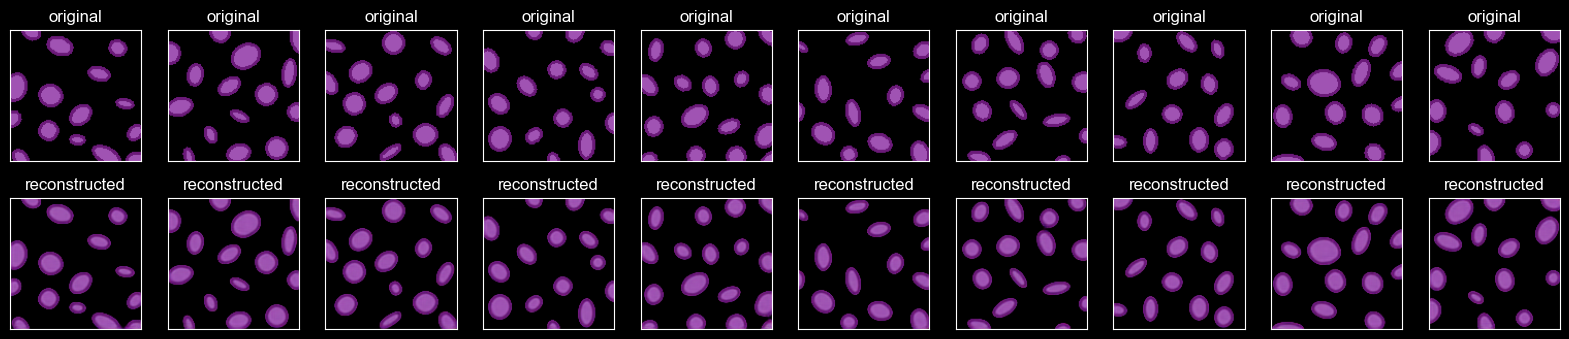

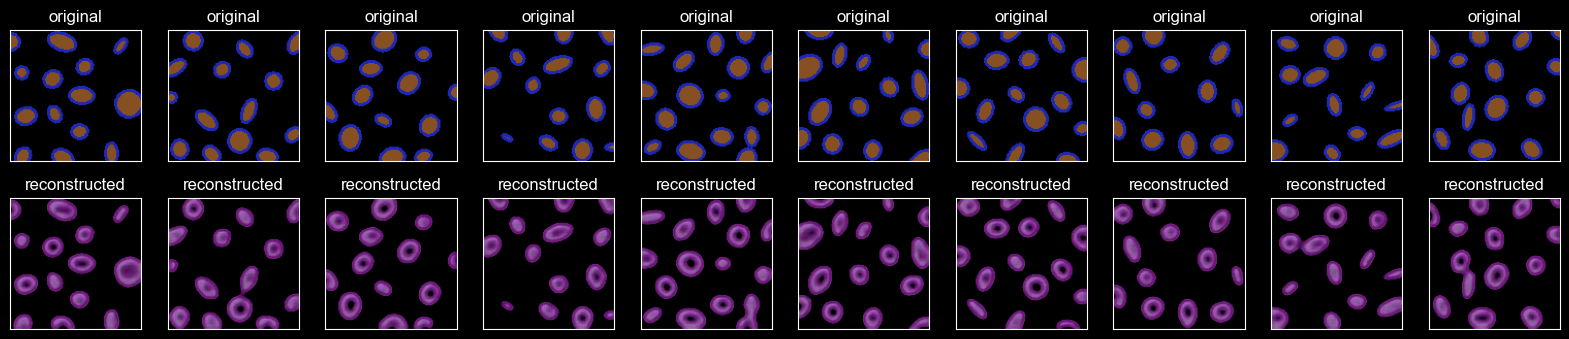

In [12]:
import keras
import numpy as np
from src.models.main import print_diag
from src.visualization.visualize_output import visualize_output
from src.models.encoder_convolutional import Encoder_conv

enkoder = Encoder_conv()

enkoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.0001,
    restore_best_weights=True
)

history = enkoder.fit(
    x_training_set, x_training_set,
    epochs=50,
    shuffle=True,
    callbacks=[early_stopping],
    validation_data=(x_val_set, x_val_set),
    verbose=1
)
decoded_normal2 = enkoder.predict(x_test_normal2)
decoded_diff_col = enkoder.predict(x_test_color)

mse_normal = enkoder.evaluate(x_test_normal2, x_test_normal2, verbose=0)[0]
mse_diff_col = enkoder.evaluate(x_test_color, x_test_color, verbose=0)[0]

print(f"\nTrening zakończony po {len(history.history['loss'])} epokach.")
print(f"MSE Normal: {mse_normal:.6f}")
print(f"MSE With different color:  {mse_diff_col:.6f}")

visualize_output(x_test_normal2, decoded_normal2, 10)

visualize_output(x_test_color, decoded_diff_col, 10)

In [13]:
color_data = {'Eksperyment': 'MSE with different color', 'Wynik': [mse_diff_col]}

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(color_data)], ignore_index=True)

mse_dataset

,Eksperyment,Wynik
0,MSE Normal,0.077211
1,MSE Large,0.233353
2,MSE with different color,0.174644


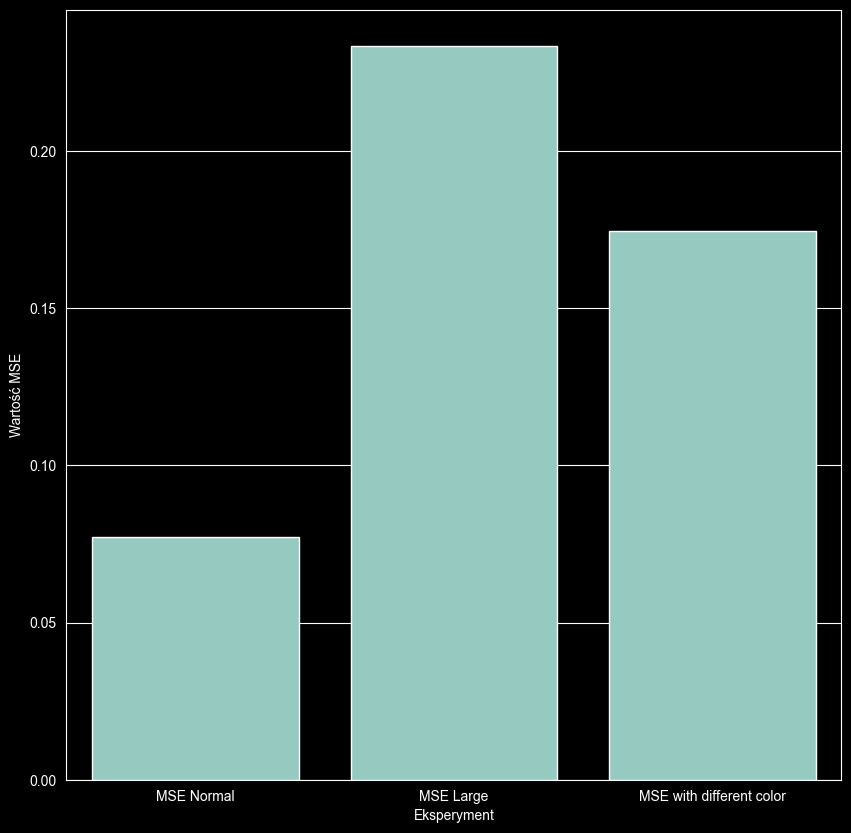

In [14]:
plt.figure(figsize=(10, 10))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()

Kolor komórek wpływa jeszcze w mniejszym stopniu na wynik błedu MSE niż w przypadku większych komórek. Enkoder jest w stanie rozpoznawać kolory

# Eksperyment trzeci
W ekspetymenie sprawdzony zostanie wpływ rozkładu komórek na błąd MSE


In [15]:
from builders.simple_generator import generate_image
from src.builders.image_builder import ImageGenerator
from src.utils.classes.config import GenerationConfig
from src.builders.simple_generator import generate_batch

distribution_conf = GenerationConfig()
distribution_conf.distribution.algorithm = 'gaussian'
img = ImageGenerator(distribution_conf)

In [16]:
set_trenning3 = generate_batch(5000)
validaion_set3 = generate_batch(1000)
test_set3 = generate_batch(2000)
distribution_test3 = img.build_batch(2000)

Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 17 centers
Generated 14 centers
Generated 17 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 13 centers
Generated 15 centers
Generated 14 centers
Generated 13 centers
Generated 17 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 13 centers
Generated 14 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 17 centers
Generated 14 centers
Generated 17 centers
Generated 15 centers
Generated 13 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 17 centers
Generated 17 centers
Generated 16 centers
Generated 16 centers
Generated 17 centers
Generated 16 centers
Generated 17 centers
Generated 18 centers
Generated 15 centers
Generated 15 

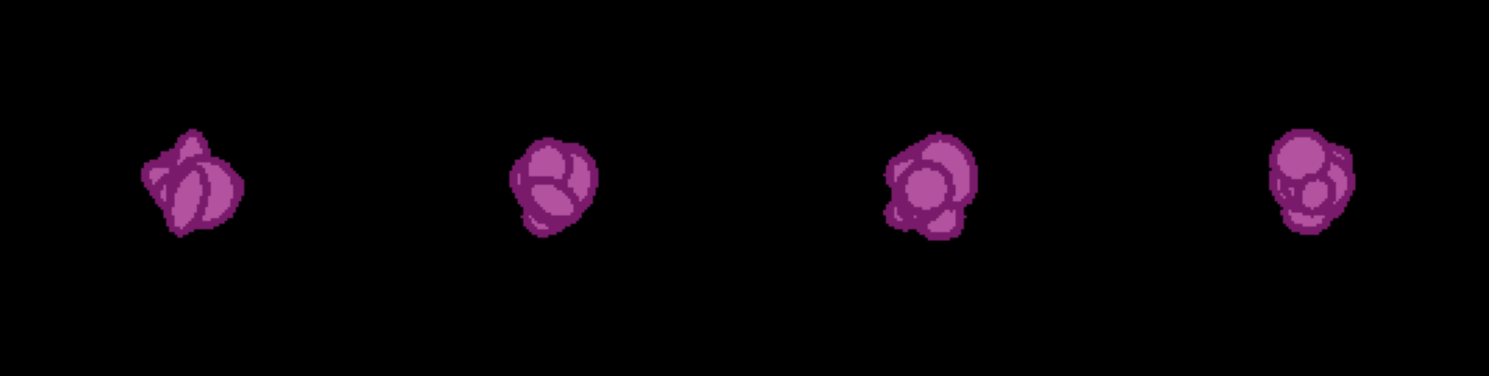

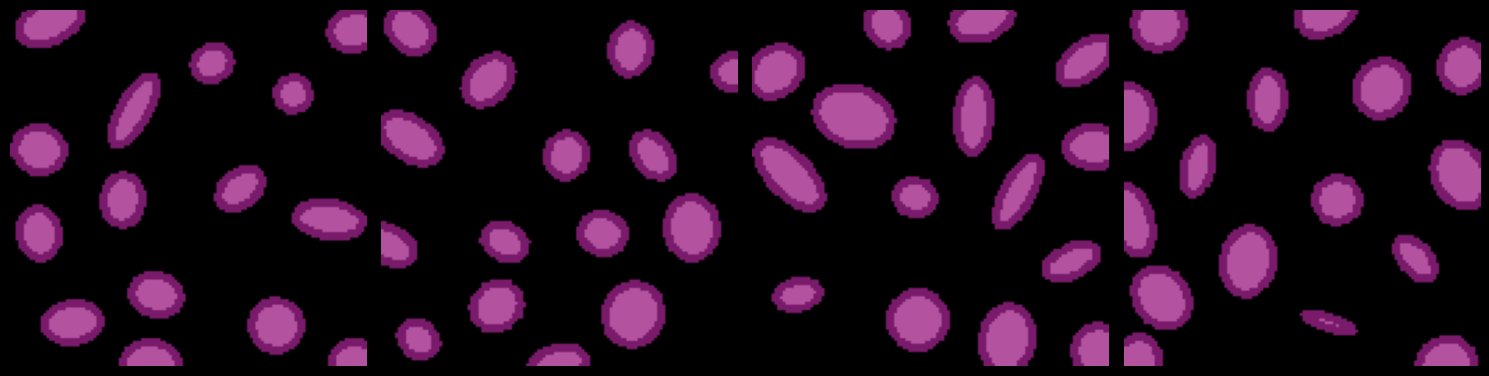

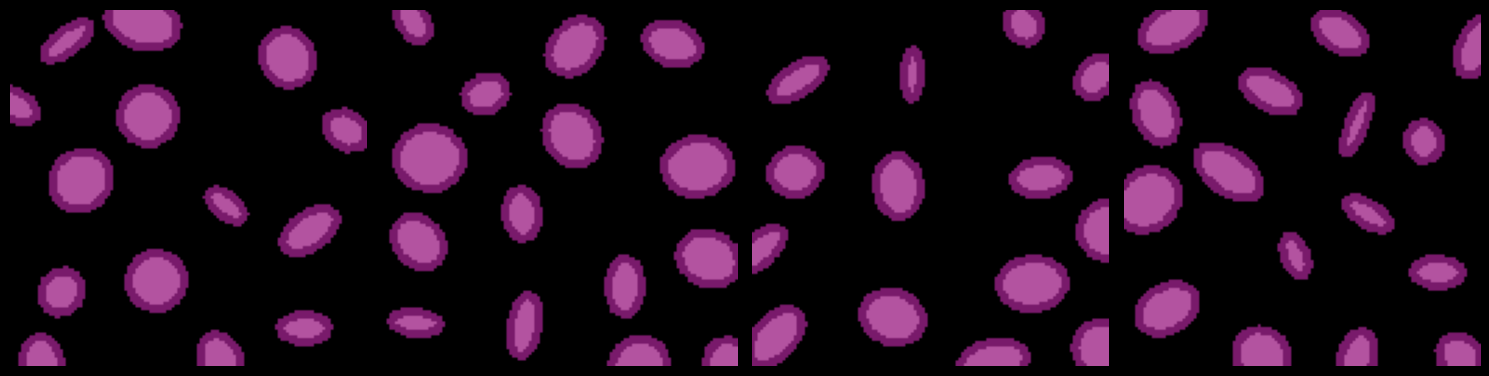

In [17]:
show_images(distribution_test3[:4])
show_images(set_trenning3[:4])
show_images(validaion_set3[:4])

In [18]:
x_test_distribution = preprocess(distribution_test3)
x_test_normal3 = preprocess(test_set3)
x_val_set3 = preprocess(validaion_set3)
x_training_set = preprocess(set_trenning3)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 140ms/step - accuracy: 0.3269 - loss: 0.1928 - mse: 0.0123 - val_accuracy: 0.3615 - val_loss: 0.1563 - val_mse: 0.0022
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 135ms/step - accuracy: 0.2948 - loss: 0.1550 - mse: 0.0019 - val_accuracy: 0.2532 - val_loss: 0.1536 - val_mse: 0.0015
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 136ms/step - accuracy: 0.2510 - loss: 0.1531 - mse: 0.0014 - val_accuracy: 0.2495 - val_loss: 0.1524 - val_mse: 0.0012
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 134ms/step - accuracy: 0.2573 - loss: 0.1525 - mse: 0.0013 - val_accuracy: 0.2657 - val_loss: 0.1526 - val_mse: 0.0013
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 135ms/step - accuracy: 0.3009 - loss: 0.1518 - mse: 0.0011 - val_accuracy: 0.3848 - val_loss: 0.1515 - val_mse: 0.0010
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 134ms/step - accuracy: 0.3865 - loss: 0.1516 - mse: 0.0010 - val_accuracy: 0.4262 - val_loss: 0.1513 - val_mse: 9.2895e-04
Epoch 7/50
157/157

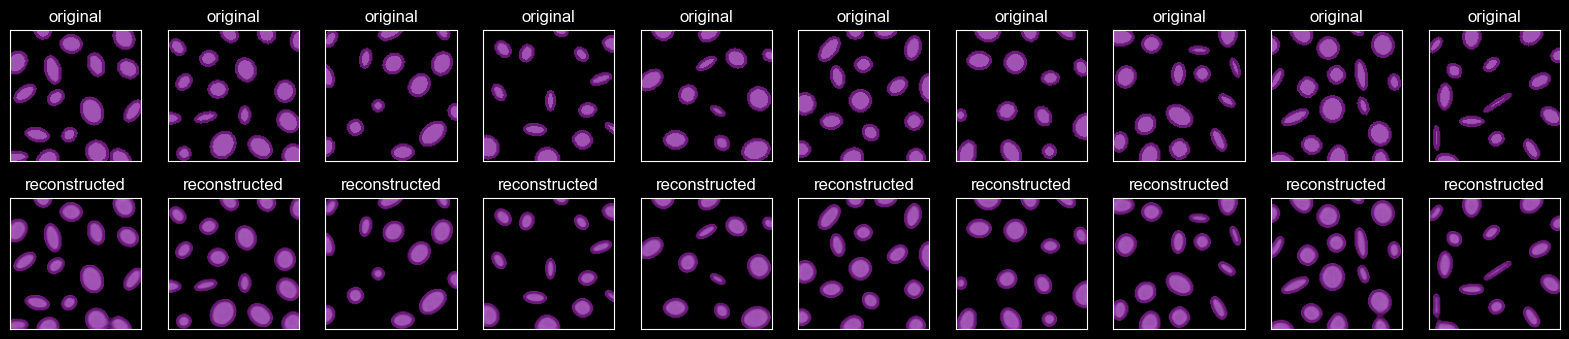

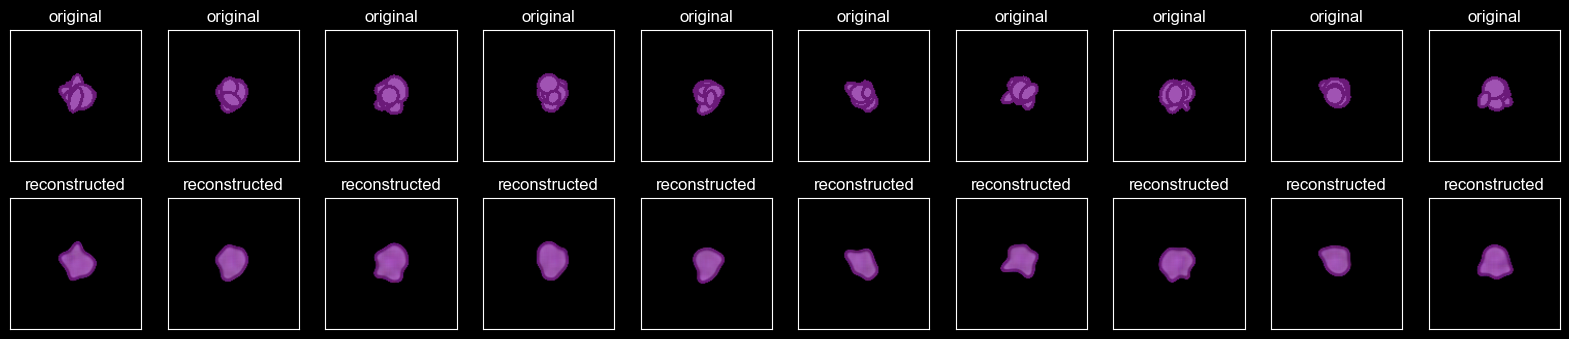

In [19]:
import keras
import numpy as np
from src.models.main import print_diag
from src.visualization.visualize_output import visualize_output
from src.models.encoder_convolutional import Encoder_conv

enkoder = Encoder_conv()

enkoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.0001,
    restore_best_weights=True
)

history = enkoder.fit(
    x_training_set, x_training_set,
    epochs=50,
    shuffle=True,
    callbacks=[early_stopping],
    validation_data=(x_val_set3, x_val_set3),
    verbose=1
)
decoded_normal3 = enkoder.predict(x_test_normal3)
decoded_distr = enkoder.predict(x_test_distribution)

mse_normal = enkoder.evaluate(x_test_normal3, x_test_normal3, verbose=0)[0]
mse_distr = enkoder.evaluate(x_test_distribution, x_test_distribution, verbose=0)[0]

print(f"\nTrening zakończony po {len(history.history['loss'])} epokach.")
print(f"MSE Normal: {mse_normal:.6f}")
print(f"MSE With different color:  {mse_diff_col:.6f}")

visualize_output(x_test_normal3, decoded_normal3, 10)

visualize_output(x_test_distribution, decoded_distr, 10)

In [20]:
dist_data = {'Eksperyment': 'MSE with different color', 'Wynik': [mse_diff_col]}

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(dist_data)], ignore_index=True)

mse_dataset

,Eksperyment,Wynik
0,MSE Normal,0.077211
1,MSE Large,0.233353
2,MSE with different color,0.174644
3,MSE with different color,0.174644


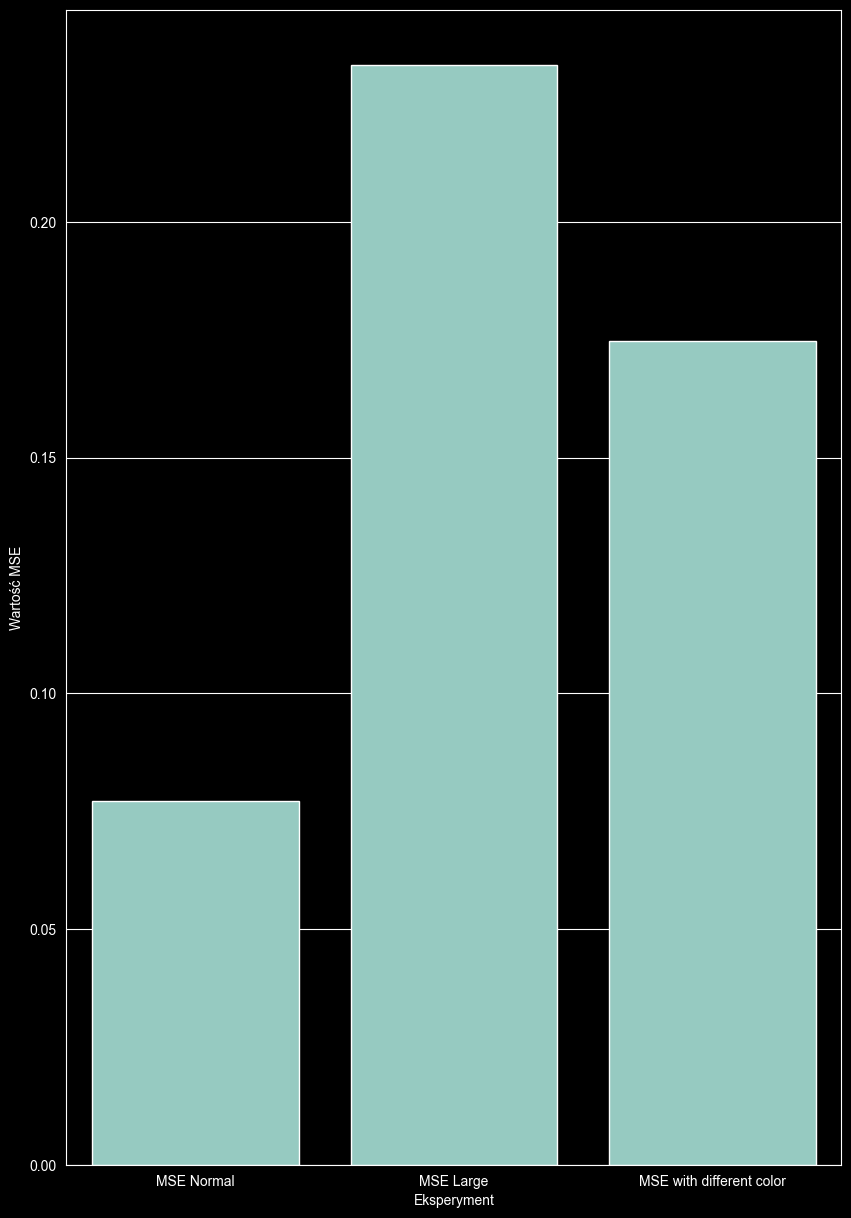

In [21]:
plt.figure(figsize=(10,15))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()